In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle
from utils.pd_utils import get_life_times
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist
from utils.passing_cells_utils import distribution_max

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.confidence import fig_bottleneck, fig_bottleneck_max

from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
# seeds = [0, 1, 2]
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

# load data!

In [ ]:
dataset = "tasic_orange"
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


In [ ]:
aa = [True, True, False]
[1 if a else 2 for a in aa ]

[1, 1, 2]

In [ ]:
whaattt = load_dict(os.path.join(root_path, dataset, f"bottleneck_dists_bootstrap_256_diffusion_k_100_t_8_kernel_sknn_include_self_False.pkl"))['bottleneck']


In [ ]:
whaattt

array([0.300276, 0.300276, 0.300276, 0.300276, 0.300276, 0.300276,
       0.300276, 0.300276, 0.300276, 0.300276, 0.300535, 0.300276,
       0.300276, 0.300276, 0.300276, 0.300276, 0.300276, 0.300276,
       0.300276, 0.300276, 0.300276, 0.300276, 0.300276, 0.300276,
       0.300276])

/tmp/ipykernel_31959/1517953069.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row].set_yticklabels([round(tick, 3) for tick in yticks], fontsize=3)
/tmp/ipykernel_31959/1517953069.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row].set_yticklabels([round(tick, 3) for tick in yticks], fontsize=3)
/tmp/ipykernel_31959/1517953069.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row].set_yticklabels([round(tick, 3) for tick in yticks], fontsize=3)
/tmp/ipykernel_31959/1517953069.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[row].set_yticklabels([round(tick, 3) for tick in yticks], fontsize=3)
/tmp/ipykernel_31959/1517953069.

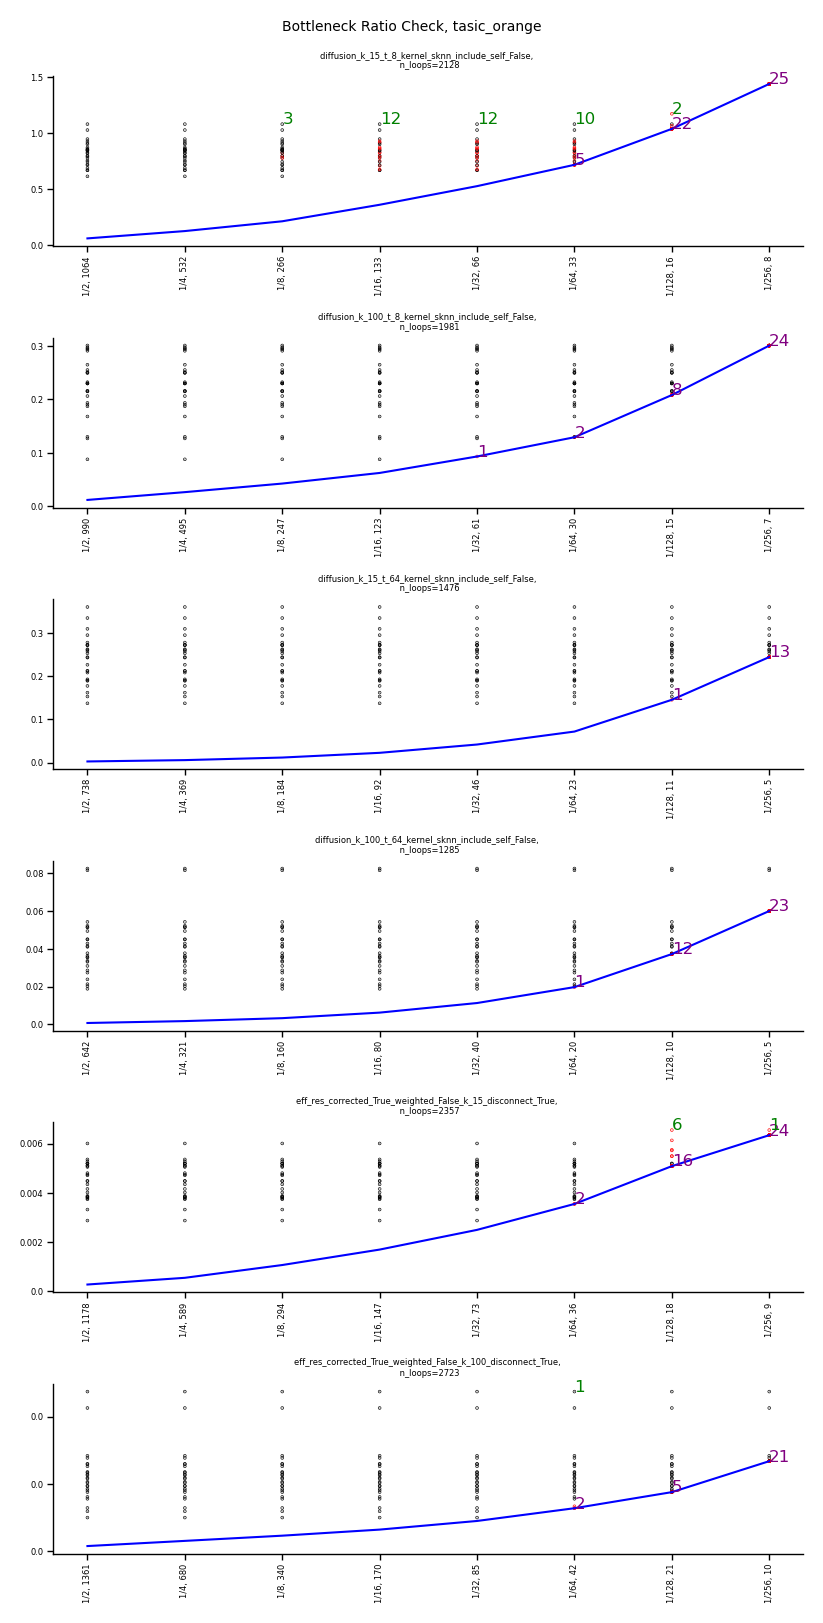

In [ ]:
ratiolist = [2, 4, 8, 16, 32, 64, 128, 256]
fig, ax = plt.subplots(6, 1, figsize=(4, 8))
row = 0
n_seeds = 25
for i, distance in enumerate(all_res.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        reference_dgm = all_res[distance][full_dist]
        n_loops = len(reference_dgm["dgms"][1])
        ax[row].set_title(f"{full_dist}, \n n_loops={n_loops}", size = 3)
        thresholds = []
        ns = []
        the_bottlenecks = load_dict(os.path.join(root_path, dataset, f"bottleneck_dists_bootstrap_half_{full_dist}.pkl"))['bottleneck']
        for ra, ratio in enumerate(ratiolist):
            
            n = int(np.floor(len(reference_dgm["dgms"][1])/int(ratio)))
            ns.append(n)
            sort_idx = np.argsort(get_life_times(reference_dgm, dim=1, mode="additive"))[::-1]
            max_del_lt = [reference_dgm['dgms'][1][sort_idx[n], 1] - reference_dgm['dgms'][1][sort_idx[n], 0]]
            for r in range(n_seeds):
                file_name = os.path.join(root_path,
                                                dataset,
                                                f"{dataset}_seed_0_bootstrap_{r}_{full_dist}_rep")
                dgm = read_ripser_result(file_name)
                sort_idx = np.argsort(get_life_times(dgm, dim=1, mode="additive"))[::-1]
                
                
                max_del_lt.append(dgm['dgms'][1][sort_idx[n], 1] - dgm['dgms'][1][sort_idx[n], 0])
            threshold = max(max_del_lt)
            thresholds.append(threshold)
            
            if ratio == 2:
                ratio_name = "half"
            elif ratio == 4:
                ratio_name = "quarter"
            else:
                ratio_name = str(ratio)

            bottlenecks = load_dict(os.path.join(root_path, dataset, f"bottleneck_dists_bootstrap_{ratio_name}_{full_dist}.pkl"))['bottleneck']
            compare = bottlenecks[:n_seeds] == the_bottlenecks[:n_seeds]
            ax[row].scatter([ra]*n_seeds, bottlenecks[:n_seeds], c=["black" if comp else "red" for comp in compare],  s = 0.2, alpha=1)
            
            mask = bottlenecks == threshold
            # print(full_dist)
            # print(ratio)
            the_sum = np.sum(mask)
            if np.sum(mask) > 0:
                ax[row].annotate(the_sum, (ra, threshold), color="purple")
            if sum(compare) != n_seeds and (n_seeds - sum(compare) - the_sum )> 0:
                ax[row].annotate(n_seeds - sum(compare) - the_sum, xy = (ra, max(bottlenecks)), color="green")
            
        ax[row].plot(range(len(ratiolist)), np.array(thresholds), color="blue")
        
        ax[row].set_xticks(range(len(ratiolist)), [f"1/{str(rat)}, {n}" for rat,n in zip(ratiolist, ns)], rotation = 90, size = 3)
        yticks = ax[row].get_yticks()
        ax[row].set_yticklabels([round(tick, 3) for tick in yticks], fontsize=3)
        row+=1
fig.suptitle(f"Bottleneck Ratio Check, {dataset}", size = 5)

fig.savefig(os.path.join(fig_path, f"bottleneck_ratio_check.png"), bbox_inches='tight')